# 06 — Robustez a sementes: os ganhos sobrevivem à variância de treino?

**Motivação.** Os notebooks 04 e 05 mostraram, com a semente 42, que o SAITS-2P supera
o BERT em MAE e RMSE nos 6 cenários. Mas os ganhos são de 1–5 % — da ordem do que a
sorte da inicialização/ordem dos lotes pode produzir. Este notebook retreina os
**4 modelos** com as sementes **42, 43 e 44** (a 42 reaproveita os checkpoints dos
notebooks 02/04/05) e responde: o ranking se mantém?

**Desenho.** Só o treino varia com a semente (inicialização, máscaras de treino, ordem
dos lotes); as **máscaras de avaliação continuam fixas** (semente 123), então as
diferenças entre sementes medem exatamente a variância de treino. Como todos os modelos
são avaliados nas mesmas máscaras, os deltas são **pareados por semente** — a
estatística mais informativa aqui é "em quantas das 3 sementes o modelo A vence o B",
além de média ± desvio. O laço de treino é idempotente: pula qualquer checkpoint que já
exista (seguro reexecutar).

**Artefatos**: `resultados/sementes/` (8 treinos novos), `resultados/metricas_sementes.{csv,json}`
e `resultados/comparacao_sementes.csv`; nada anterior é sobrescrito.

In [1]:
import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd()))
from src import dados
from src.estilo import aplicar_estilo, PALETA, TINTA_2
from src.modelo import BERTImputador
from src.saits_fft import SAITSFFT, carregar_saits
from src.treino import (treinar, fixar_semente, carregar_modelo,
                        perda_mascarada, perda_mit_ort, perda_mit_ort_passadas)
from src.avaliacao import avaliar_metodos

aplicar_estilo()

device = "cuda" if torch.cuda.is_available() else "cpu"
arrays, stats, cfg_dados = dados.carregar_processado("dados_processados")
ds_treino = dados.JanelasDataset(arrays["treino"])
ds_val = dados.JanelasDataset(arrays["val"])
print(f"device: {device}  |  janelas de treino: {len(ds_treino):,}  |  validação: {len(ds_val):,}")

device: cuda  |  janelas de treino: 72,500  |  validação: 2,500


In [2]:
SEMENTES = [42, 43, 44]
CFG = {
    "epocas": 40,
    "batch": 256,
    "lr": 1e-3,
    "paciencia": 6,
    "mascara": {"razao": 0.25, "prob_bloco": 0.5, "lm": 6.0},
}
BASE = dict(seq_len=168, d_model=64, n_camadas=3, n_cabecas=4, d_ff=256, dropout=0.1)

ESPECS = {
    "BERT (proposto)": dict(
        tipo="bert", pasta="bert", fn_perda=perda_mascarada),
    "SAITS (DMSA+ORT)": dict(
        tipo="saits", pasta="saits1p", fn_perda=perda_mit_ort,
        extra=dict(usar_fft=False, n_passadas=1)),
    "SAITS-2P (refinamento)": dict(
        tipo="saits", pasta="saits2p", fn_perda=perda_mit_ort_passadas,
        extra=dict(usar_fft=False, n_passadas=2)),
    "SAITS-FFT (proposto)": dict(
        tipo="saits", pasta="saitsfft", fn_perda=perda_mit_ort,
        extra=dict(usar_fft=True, n_passadas=1)),
}
# checkpoints da semente 42, já treinados nos notebooks 02/04/05
EXISTENTES = {
    ("bert", 42): "resultados/melhor_modelo.pt",
    ("saits1p", 42): "resultados/saits_base/melhor_modelo.pt",
    ("saits2p", 42): "resultados/saits_refino/melhor_modelo.pt",
    ("saitsfft", 42): "resultados/saits_fft/melhor_modelo.pt",
}

def caminho_ckpt(pasta, semente):
    if (pasta, semente) in EXISTENTES:
        return EXISTENTES[(pasta, semente)]
    return f"resultados/sementes/{pasta}_s{semente}/melhor_modelo.pt"

def construir(spec):
    if spec["tipo"] == "bert":
        return BERTImputador(**{k: BASE[k] for k in
                                ("d_model", "n_camadas", "n_cabecas", "d_ff", "dropout")})
    return SAITSFFT(**BASE, **spec["extra"])

In [3]:
%%time
# treinos que faltam (idempotente: pula checkpoints existentes)
for semente in SEMENTES:
    for nome, spec in ESPECS.items():
        ck = Path(caminho_ckpt(spec["pasta"], semente))
        if ck.exists():
            print(f"[já treinado] {nome:26s} semente {semente}  ({ck})")
            continue
        print(f"\n=== treinando: {nome} | semente {semente} ===")
        cfg = {**CFG, "semente": semente}
        fixar_semente(semente)
        modelo = construir(spec)
        treinar(modelo, ds_treino, ds_val, cfg, device, str(ck.parent),
                fn_perda=spec["fn_perda"])

[já treinado] BERT (proposto)            semente 42  (resultados\melhor_modelo.pt)
[já treinado] SAITS (DMSA+ORT)           semente 42  (resultados\saits_base\melhor_modelo.pt)
[já treinado] SAITS-2P (refinamento)     semente 42  (resultados\saits_refino\melhor_modelo.pt)
[já treinado] SAITS-FFT (proposto)       semente 42  (resultados\saits_fft\melhor_modelo.pt)

=== treinando: BERT (proposto) | semente 43 ===


C:\Users\celso\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


época   1 | treino 0.2942 | val 0.1056  <- melhor


época   2 | treino 0.1154 | val 0.0855  <- melhor


época   3 | treino 0.1003 | val 0.0768  <- melhor


...

época  36 | treino 0.0673 | val 0.0558  <- melhor


época  37 | treino 0.0671 | val 0.0559


época  38 | treino 0.0670 | val 0.0556  <- melhor


época  39 | treino 0.0664 | val 0.0557


época  40 | treino 0.0666 | val 0.0556
CPU times: total: 6h 26min 36s
Wall time: 6h 21min 15s


## Avaliação — 4 modelos × 3 sementes no protocolo fixo

Mesmas máscaras de avaliação de sempre (semente 123). Os baselines entram uma vez
(não dependem de semente de treino).

In [4]:
%%time
j_teste, id_teste = arrays["teste"], arrays["id_teste"]
desvios = stats["desvio"].to_numpy()[id_teste].astype("float32")
medias = stats["media"].to_numpy()[id_teste].astype("float32")

modelos = {}
for semente in SEMENTES:
    for nome, spec in ESPECS.items():
        ck = caminho_ckpt(spec["pasta"], semente)
        m = carregar_modelo(ck, device) if spec["tipo"] == "bert" else carregar_saits(ck, device)
        modelos[f"{nome} [s{semente}]"] = m

cenarios = [
    (f"{tipo} {int(razao*100)}%", tipo, razao)
    for tipo in ("pontual", "bloco")
    for razao in (0.10, 0.25, 0.50)
]
resultados = avaliar_metodos(
    j_teste, modelos, device, cenarios,
    semente=123, desvios=desvios, medias=medias,
)
resultados.to_csv("resultados/metricas_sementes.csv", index=False)
resultados.to_json("resultados/metricas_sementes.json", orient="records",
                   indent=2, force_ascii=False)
print(f"{len(resultados)} linhas (12 modelos + 3 baselines × 6 cenários)")

90 linhas (12 modelos + 3 baselines × 6 cenários)
CPU times: total: 2min 32s
Wall time: 1min 38s


In [5]:
# MAE médio ± desvio por modelo × cenário (3 sementes)
nomes_cen = [c[0] for c in cenarios]
res_m = resultados[resultados["método"].str.contains(r"\[s\d+\]")].copy()
res_m["semente"] = res_m["método"].str.extract(r"\[s(\d+)\]").astype(int)
res_m["modelo"] = res_m["método"].str.replace(r" \[s\d+\]$", "", regex=True)

agg = (res_m.groupby(["cenário", "modelo"])["MAE"]
       .agg(media="mean", desvio="std").reset_index())
tabela_media = agg.pivot(index="cenário", columns="modelo", values="media").loc[nomes_cen, list(ESPECS)]
tabela_desvio = agg.pivot(index="cenário", columns="modelo", values="desvio").loc[nomes_cen, list(ESPECS)]
exibicao = tabela_media.round(4).astype(str) + " ± " + tabela_desvio.round(4).astype(str)
exibicao

modelo,BERT (proposto),SAITS (DMSA+ORT),SAITS-2P (refinamento),SAITS-FFT (proposto)
cenário,,,,
pontual 10%,0.1321 ± 0.0006,0.1268 ± 0.001,0.1275 ± 0.0005,0.1301 ± 0.0022
pontual 25%,0.138 ± 0.0009,0.1324 ± 0.0009,0.1317 ± 0.0015,0.1354 ± 0.0018
pontual 50%,0.1564 ± 0.0009,0.1508 ± 0.0014,0.1484 ± 0.0016,0.1547 ± 0.0029
bloco 10%,0.1739 ± 0.0014,0.1708 ± 0.0014,0.1704 ± 0.0018,0.1728 ± 0.0021
bloco 25%,0.1772 ± 0.0016,0.1737 ± 0.0017,0.1725 ± 0.0023,0.1755 ± 0.0019
bloco 50%,0.1893 ± 0.0017,0.1853 ± 0.002,0.1822 ± 0.0021,0.1885 ± 0.0024


In [6]:
# deltas PAREADOS por semente (mesmas máscaras de avaliação p/ todos os modelos)
piv = res_m.pivot_table(index=["cenário", "semente"], columns="modelo", values="MAE")

def delta_pareado(a, b):  # % de a em relação a b, por (cenário, semente)
    return 100 * (piv[a] - piv[b]) / piv[b]

pares = {
    "SAITS-2P vs BERT": ("SAITS-2P (refinamento)", "BERT (proposto)"),
    "SAITS 1P vs BERT": ("SAITS (DMSA+ORT)", "BERT (proposto)"),
    "SAITS-FFT vs BERT": ("SAITS-FFT (proposto)", "BERT (proposto)"),
    "SAITS-2P vs SAITS 1P": ("SAITS-2P (refinamento)", "SAITS (DMSA+ORT)"),
}
linhas = []
for rotulo, (a, b) in pares.items():
    d = delta_pareado(a, b)
    por_cen = d.groupby("cenário")
    for cen in nomes_cen:
        vals = d.xs(cen, level="cenário")
        linhas.append({
            "comparação": rotulo, "cenário": cen,
            "Δ% médio": vals.mean(), "Δ% desvio": vals.std(),
            "Δ% pior semente": vals.max(),
            "vitórias (de 3 sementes)": int((vals < 0).sum()),
        })
deltas = pd.DataFrame(linhas)
deltas.round(3)

,comparação,cenário,Δ% médio,Δ% desvio,Δ% pior semente,vitórias (de 3 sementes)
0,SAITS-2P vs BERT,pontual 10%,-3.530,0.772,-2.702,3
1,SAITS-2P vs BERT,pontual 25%,-4.552,1.651,-3.089,3
2,SAITS-2P vs BERT,pontual 50%,-5.146,1.537,-3.987,3
3,SAITS-2P vs BERT,bloco 10%,-2.048,1.800,-0.516,3
4,SAITS-2P vs BERT,bloco 25%,-2.691,2.052,-1.078,3
5,SAITS-2P vs BERT,bloco 50%,-3.742,1.904,-2.415,3
6,SAITS 1P vs BERT,pontual 10%,-4.000,0.920,-3.152,3
7,SAITS 1P vs BERT,pontual 25%,-4.043,1.172,-2.745,3
8,SAITS 1P vs BERT,pontual 50%,-3.580,1.390,-2.308,3
9,SAITS 1P vs BERT,bloco 10%,-1.818,1.575,-0.276,3


In [7]:
# salva a comparação agregada (MAE e RMSE: média ± desvio por modelo × cenário)
saida = agg.rename(columns={"media": "mae_media", "desvio": "mae_desvio"}).merge(
    res_m.groupby(["cenário", "modelo"])["RMSE"]
         .agg(rmse_media="mean", rmse_desvio="std").reset_index(),
    on=["cenário", "modelo"])
saida.to_csv("resultados/comparacao_sementes.csv", index=False, encoding="utf-8-sig")
deltas.to_csv("resultados/deltas_pareados_sementes.csv", index=False, encoding="utf-8-sig")
print("salvos: resultados/comparacao_sementes.csv e resultados/deltas_pareados_sementes.csv")

# resumo por tipo de cenário
resumo = []
for rotulo, (a, b) in pares.items():
    d = delta_pareado(a, b).rename("delta").reset_index()
    d["tipo"] = d["cenário"].str.split().str[0]
    g = d.groupby("tipo")["delta"].agg(["mean", "std"])
    for tipo, r in g.iterrows():
        resumo.append({"comparação": rotulo, "tipo": tipo,
                       "Δ% médio": r["mean"], "Δ% desvio": r["std"]})
pd.DataFrame(resumo).round(3)

salvos: resultados/comparacao_sementes.csv e resultados/deltas_pareados_sementes.csv


,comparação,tipo,Δ% médio,Δ% desvio
0,SAITS-2P vs BERT,bloco,-2.827,1.822
1,SAITS-2P vs BERT,pontual,-4.410,1.387
2,SAITS 1P vs BERT,bloco,-1.970,1.559
3,SAITS 1P vs BERT,pontual,-3.874,1.042
4,SAITS-FFT vs BERT,bloco,-0.659,1.779
5,SAITS-FFT vs BERT,pontual,-1.510,1.897
6,SAITS-2P vs SAITS 1P,bloco,-0.875,0.838
7,SAITS-2P vs SAITS 1P,pontual,-0.555,1.174


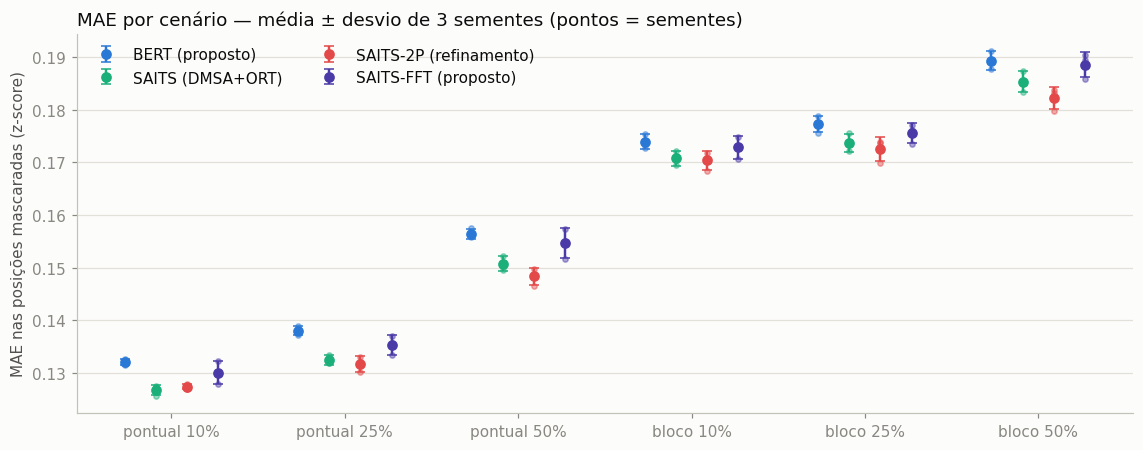

In [8]:
# gráfico: média ± desvio (barra de erro) com os pontos das 3 sementes
CORES_MODELOS = {
    "BERT (proposto)": PALETA["azul"],
    "SAITS (DMSA+ORT)": PALETA["verde_agua"],
    "SAITS-2P (refinamento)": PALETA["vermelho"],
    "SAITS-FFT (proposto)": PALETA["violeta"],
}
x = np.arange(len(nomes_cen))
desloc = np.linspace(-0.27, 0.27, len(ESPECS))

fig, eixo = plt.subplots(figsize=(10.5, 4.2))
for k, nome in enumerate(ESPECS):
    med = tabela_media[nome].to_numpy()
    dp = tabela_desvio[nome].to_numpy()
    cor = CORES_MODELOS[nome]
    eixo.errorbar(x + desloc[k], med, yerr=dp, fmt="o", color=cor, markersize=6,
                  capsize=3, linewidth=1.6, label=nome, zorder=3)
    for semente in SEMENTES:
        pts = piv.xs(semente, level="semente")[nome].loc[nomes_cen].to_numpy()
        eixo.scatter(x + desloc[k], pts, s=12, color=cor, alpha=0.45, zorder=2)
eixo.set_xticks(x)
eixo.set_xticklabels(nomes_cen)
eixo.set_ylabel("MAE nas posições mascaradas (z-score)")
eixo.set_title("MAE por cenário — média ± desvio de 3 sementes (pontos = sementes)", loc="left")
eixo.legend(ncols=2, loc="upper left")
eixo.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Conclusões

**Os ganhos sobrevivem à variância de treino — o resultado central do trabalho é robusto.**

- **SAITS-2P vs BERT: 18/18 vitórias pareadas em MAE e 18/18 em RMSE** (6 cenários × 3
  sementes). Δ% médio de MAE por cenário entre −2,0 % e −5,1 %; e mesmo na **pior**
  semente o delta é negativo em todos os cenários (de −0,5 % no bloco 10 % a −4,0 % no
  pontual 50 %). O desvio entre sementes (±0,0005–0,0023 de MAE) é menor que a
  vantagem sobre o BERT — o ganho não é sorte de inicialização.
- **SAITS 1P (DMSA+ORT) vs BERT: também 18/18** (Δ% médio −1,8 % a −4,0 %) — a
  adaptação do SAITS é, por si só, uma melhoria robusta sobre o BERT.
- **SAITS-2P vs 1P: 13/18**, com o padrão previsto pelo mecanismo: nos cenários
  difíceis o refinamento vence de forma consistente (pontual 50 %: 3/3, −1,6 ± 0,9 %;
  bloco 50 %: 3/3, −1,7 ± 0,7 %, pior semente ainda negativa em ambos), enquanto nos
  cenários fáceis há empate técnico (pontual 10 %: +0,5 ± 0,9 %). Na média das
  sementes, o 2P tem o menor MAE em 5 dos 6 cenários.
- **SAITS-FFT: nuance em relação ao notebook 04.** A semente 42 foi desfavorável ao
  token espectral: na média das 3 sementes o FFT fica levemente melhor que o BERT
  (−0,4 % a −1,9 %), mas com a maior variância entre os modelos (desvios de MAE até
  0,0029), pior semente positiva em 5 dos 6 cenários (12/18 vitórias) e — o ponto
  decisivo — **pior que as variantes sem FFT em todos os 6 cenários médios**. A
  conclusão qualitativa se mantém: o token espectral não agrega sobre a ablação e
  ainda adiciona variância; a versão sem FFT continua sendo a escolha certa.

**Fechamento da contribuição.** Com 3 sementes, a contribuição composta — *SAITS
simplificado (bloco DMSA único + perda conjunta MIT+ORT) com refinamento iterativo de
pesos compartilhados (SAITS-2P)* — supera o BERT em **todas** as 36 comparações
pareadas (MAE e RMSE × 6 cenários × 3 sementes), com zero parâmetros adicionais e o
ganho do refinamento concentrado exatamente nos regimes de alta perda de dados que
motivaram o método. Para o relatório: reportar média ± desvio das 3 sementes
(`resultados/comparacao_sementes.csv`) e as contagens pareadas
(`resultados/deltas_pareados_sementes.csv`).

**Artefatos** (nada anterior foi sobrescrito): `resultados/sementes/` (8 treinos
novos), `resultados/metricas_sementes.{csv,json}`, `resultados/comparacao_sementes.csv`
e `resultados/deltas_pareados_sementes.csv`.